<a href="https://colab.research.google.com/github/komalavallisundaram/calorie-burn-prediction-/blob/main/ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
!pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans




In [24]:
from google.colab import files
df = pd.read_csv("/content/Fitbit_dataset.csv")
df.head()

,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,HIIT,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,Yoga,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,Cardio,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7


In [44]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"/content/Fitbit_dataset.csv")
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df.columns = df.columns.str.strip()

df = df.fillna(df.mean(numeric_only=True))
for col in df.select_dtypes(include=['object']).columns:
    if not df[col].empty:
        df[col] = df[col].fillna(df[col].mode()[0])
df = df.drop_duplicates()

if 'Age' in df.columns:
    df['Age'] = df['Age'].astype(int)
if 'Weight (kg)' in df.columns:
    df['Weight (kg)'] = df['Weight (kg)'].astype(float)
if 'Height (m)' in df.columns:
    df['Height (m)'] = df['Height (m)'].astype(float)
if 'Session_Duration (hours)' in df.columns:
    df['Session_Duration (hours)'] = df['Session_Duration (hours)'].astype(float)
if 'Water_Intake (liters)' in df.columns:
    df['Water_Intake (liters)'] = df['Water_Intake (liters)'].astype(float)

if 'Workout_Type' in df.columns:
    df['Workout_Type'] = df['Workout_Type'].str.strip().str.title()
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].str.strip().str.capitalize()
if 'Experience_Level' in df.columns:
    df['Experience_Level'] = df['Experience_Level'].astype(str).str.strip()

for col in ['Weight (kg)', 'Height (m)', 'Avg_BPM', 'Session_Duration (hours)', 'Calories_Burned (kcal)']:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = np.where(df[col] > upper_bound, upper_bound,
                           np.where(df[col] < lower_bound, lower_bound, df[col]))

if 'Age' in df.columns:
    df = df[df['Age'] > 0]
if 'Avg_BPM' in df.columns:
    df = df[(df['Avg_BPM'] > 40) & (df['Avg_BPM'] < 220)]
if 'Max_BPM' in df.columns:
    df = df[(df['Max_BPM'] > 60) & (df['Max_BPM'] < 250)]
if 'Session_Duration (hours)' in df.columns:
    df = df[df['Session_Duration (hours)'] > 0]

if 'Calories_Burned (kcal)' in df.columns:
    df['Calories_Burned (kcal)_log'] = np.log1p(df['Calories_Burned (kcal)'])

df.to_csv(r"/content/cleaned_Fitbit_dataset.csv", index=False)

print("✅ Full data cleaning completed. Dataset shape:", df.shape)
print("Remaining missing values:\n", df.isnull().sum())
print("✅ Cleaned dataset saved as cleaned_Fitbit_dataset.csv")


✅ Full data cleaning completed. Dataset shape: (14102, 19)
Remaining missing values:
 Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
Base_MET                         0
HR_Intensity                     0
Effective_MET                    0
Calories_Burned (kcal)           0
Calories_Burned (kcal)_log       0
dtype: int64
✅ Cleaned dataset saved as cleaned_Fitbit_dataset.csv


Unique Experience Levels: [1 0 3 2]


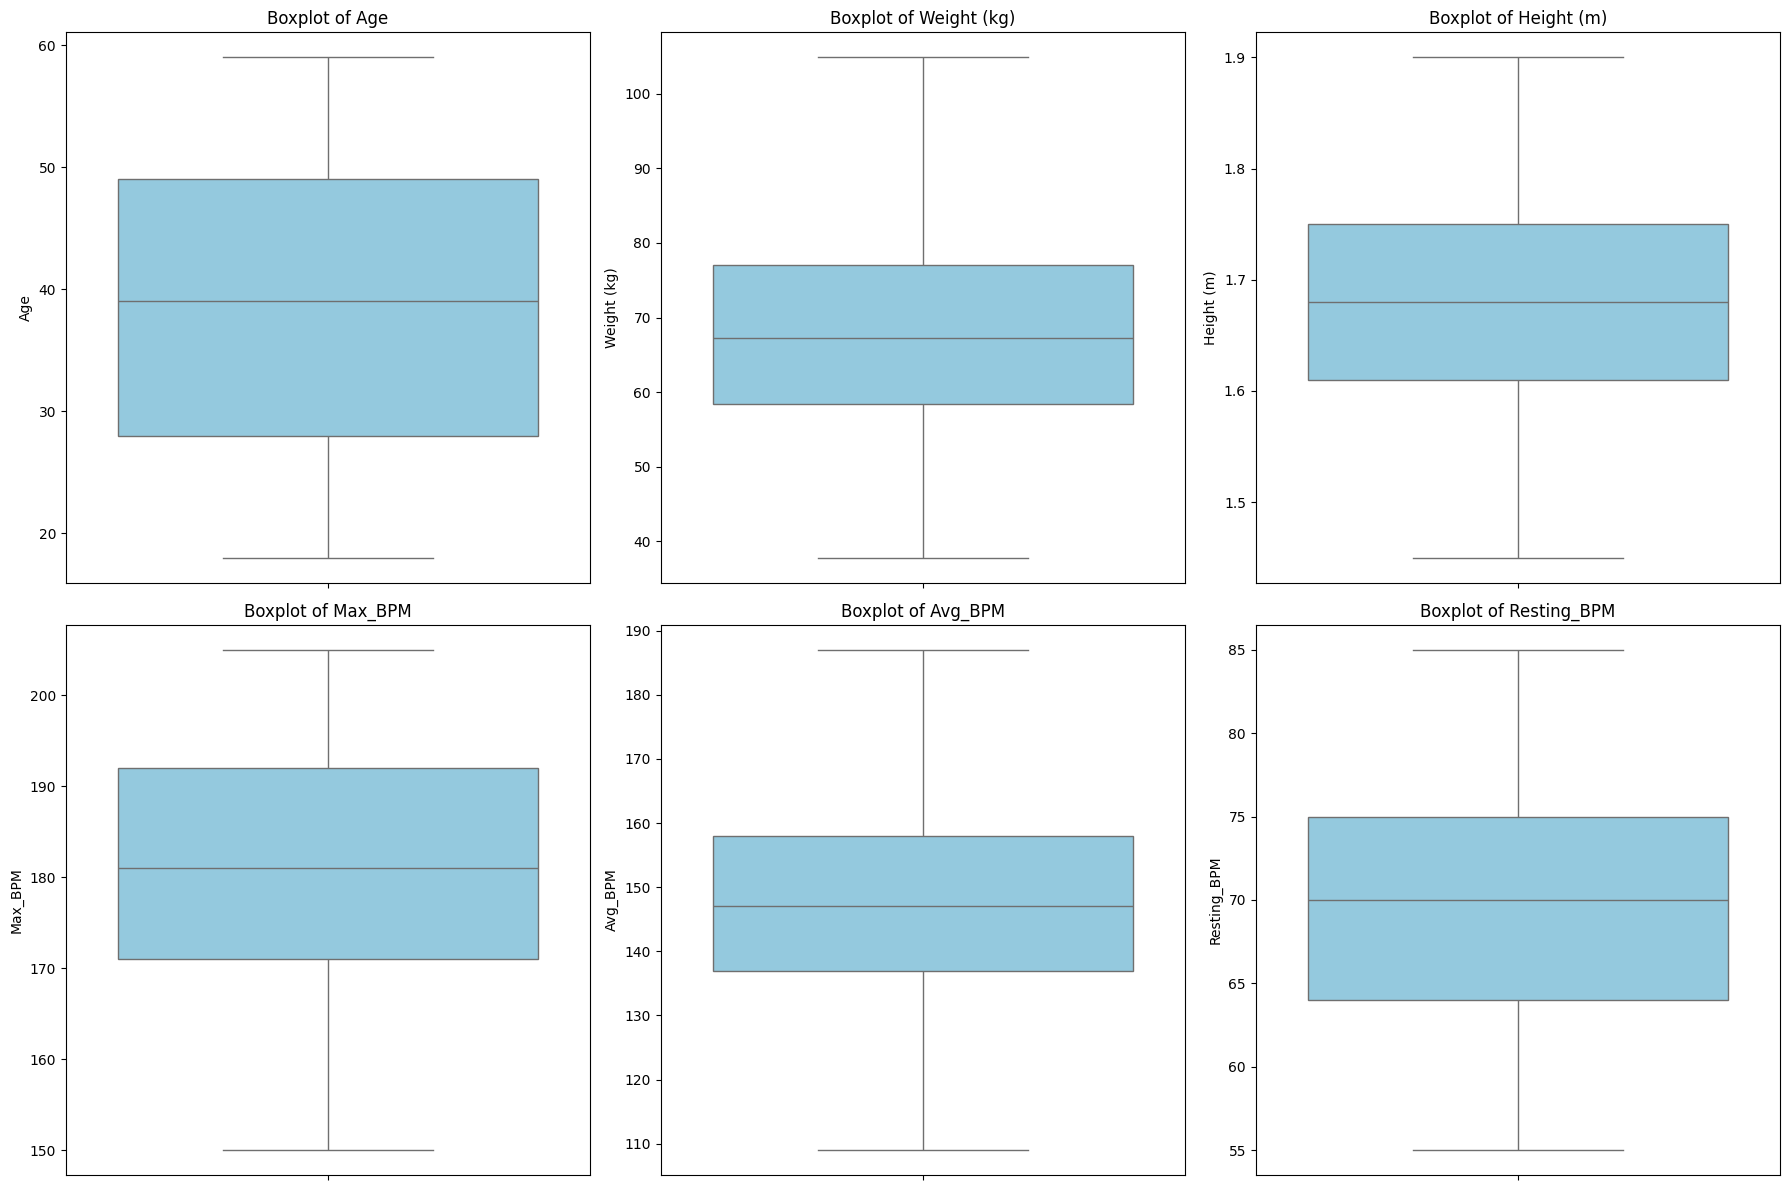

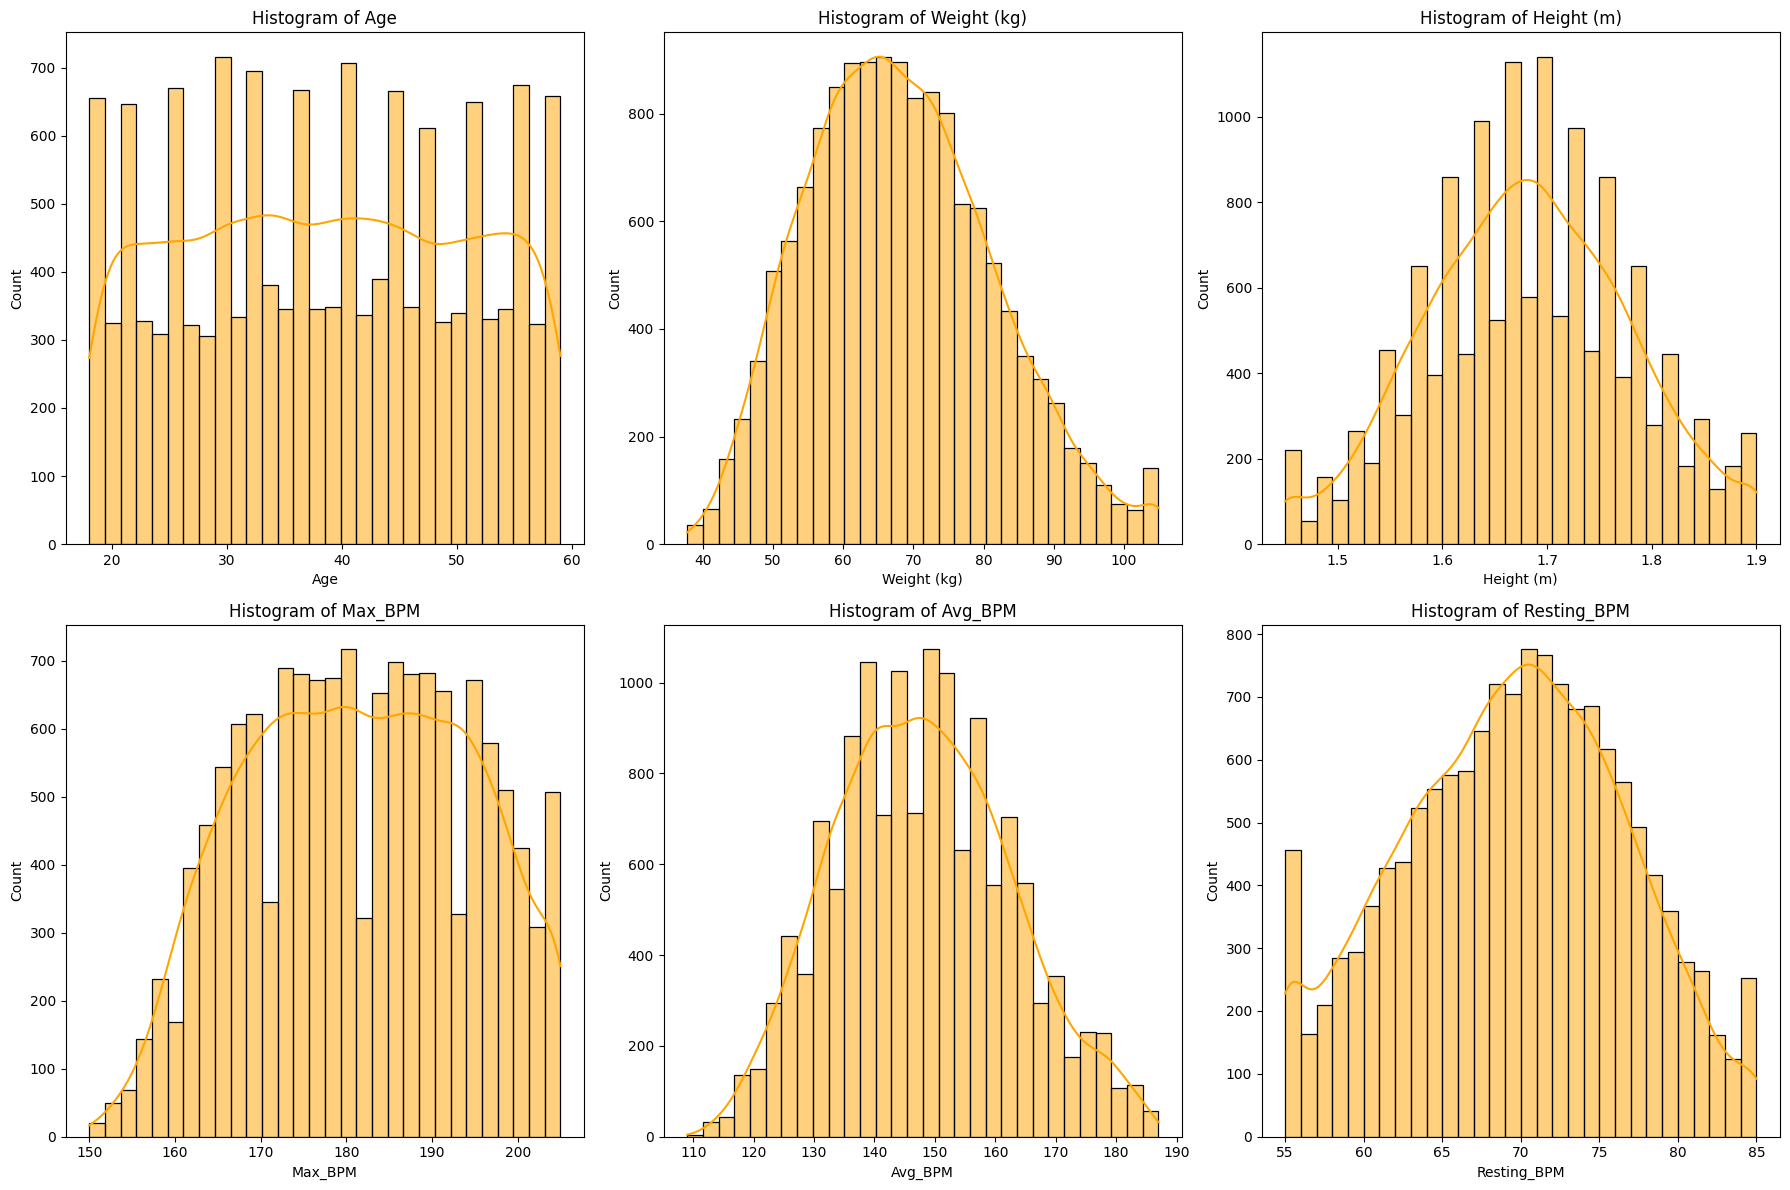

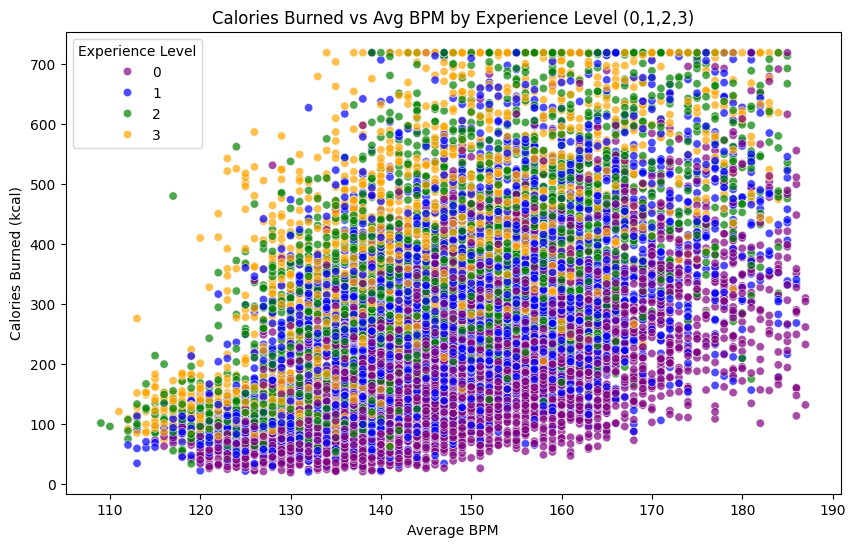

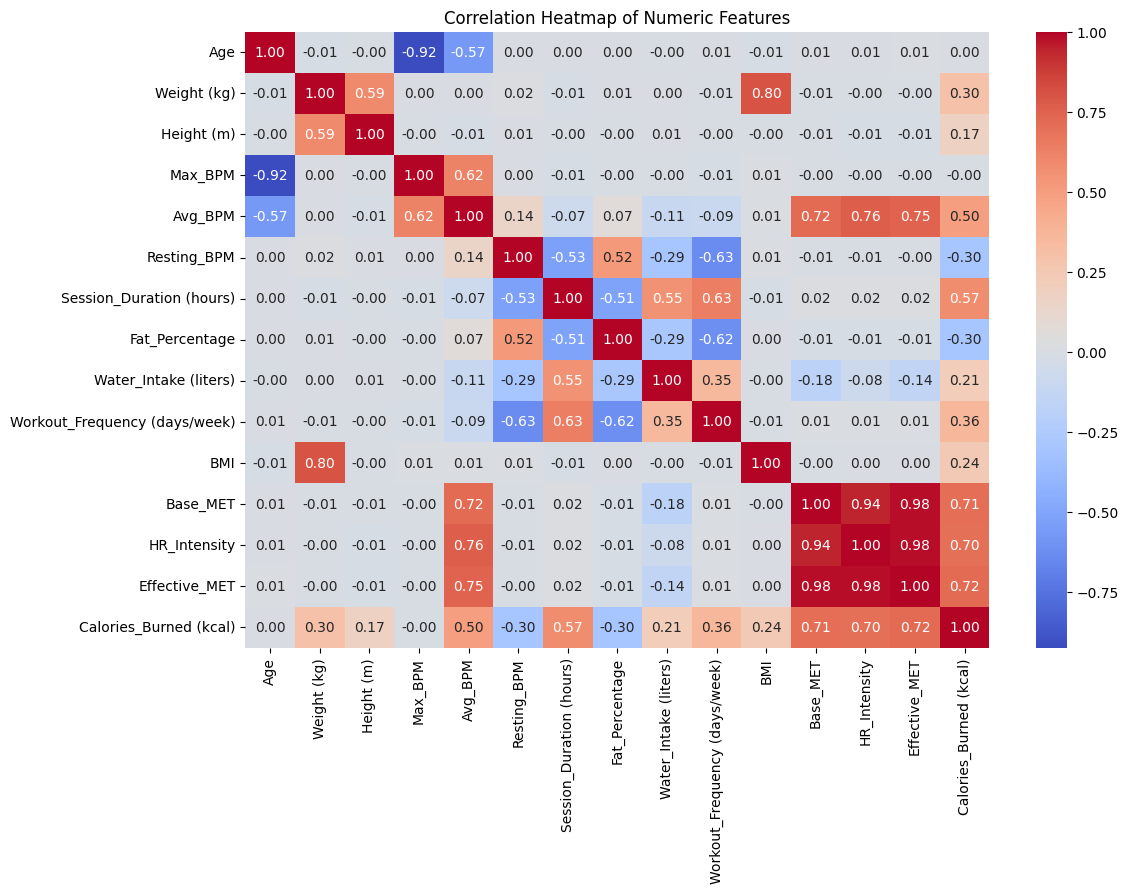

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"/content/cleaned_Fitbit_dataset.csv")

print("Unique Experience Levels:", df['Experience_Level'].unique())

numeric_cols = ['Age','Weight (kg)','Height (m)','Max_BPM','Avg_BPM',
                'Resting_BPM','Session_Duration (hours)','Fat_Percentage',
                'Water_Intake (liters)','Workout_Frequency (days/week)',
                'BMI','Base_MET','HR_Intensity','Effective_MET','Calories_Burned (kcal)']

plt.figure(figsize=(18,12))
for i, col in enumerate(numeric_cols[:6]):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(18,12))
for i, col in enumerate(numeric_cols[:6]):
    plt.subplot(2,3,i+1)
    sns.histplot(df[col], bins=30, kde=True, color='orange')
    plt.title(f"Histogram of {col}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Avg_BPM',
    y='Calories_Burned (kcal)',
    hue='Experience_Level',   # use numeric values directly
    palette={0:'purple',1:'blue',2:'green',3:'orange'},  # numeric keys
    alpha=0.7
)
plt.title("Calories Burned vs Avg BPM by Experience Level (0,1,2,3)")
plt.xlabel("Average BPM")
plt.ylabel("Calories Burned (kcal)")
plt.legend(title="Experience Level")
plt.show()

plt.figure(figsize=(12,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


In [28]:
print(df.columns)


Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Workout_Type',
       'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Base_MET',
       'HR_Intensity', 'Effective_MET', 'Calories_Burned (kcal)',
       'Calories_Burned (kcal)_log'],
      dtype='object')


In [46]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

df['BMI'] = df['Weight (kg)'] / (df['Height (m)']**2)

df['Age_Group'] = pd.cut(df['Age'], bins=[18, 30, 45, 60],
                         labels=['Young', 'Adult', 'Senior'])

df['Workout_Intensity'] = pd.cut(df['Avg_BPM'], bins=[100, 130, 160, 200],
                                 labels=['Low', 'Moderate', 'High'])

df['HR_Intensity'] = df['Avg_BPM'] / df['Max_BPM']

df['Effective_MET'] = df['Base_MET'] * df['HR_Intensity']

target_col = [col for col in df.columns if "calories_burned" in col.lower()]
if not target_col:
    raise ValueError("Target column not found. Please check dataset columns.")
else:
    target_col = target_col[0]

X = df.drop(columns=[target_col])
y = df[target_col]

df.fillna(df.mean(numeric_only=True), inplace=True)

categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns detected:", categorical_cols)

for col in categorical_cols:
    X[col] = LabelEncoder().fit_transform(X[col])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df.to_csv("processed_dataset.csv", index=False)

print("✅ Feature engineering + preprocessing completed.")
print("Dataset shape:", df.shape)
print("Processed dataset saved as 'FE+Preprocessing.csv'")
print("Preview of processed dataset:")
print(df.head())


Categorical columns detected: ['Gender', 'Workout_Type', 'Age_Group', 'Workout_Intensity']
✅ Feature engineering + preprocessing completed.
Dataset shape: (14102, 21)
Processed dataset saved as 'FE+Preprocessing.csv'
Preview of processed dataset:
   Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0   56  Female         53.8        1.62    163.0    149.0         71.0   
1   46    Male         54.9        1.75    170.0    126.0         73.0   
2   32  Female         68.5        1.61    190.0    171.0         60.0   
3   25    Male         98.8        1.86    189.0    135.0         69.0   
4   38    Male         95.5        1.71    176.0    138.0         66.0   

   Session_Duration (hours) Workout_Type  Fat_Percentage  ...  \
0                      1.01         Hiit            22.1  ...   
1                      0.25         Yoga            19.9  ...   
2                      0.33         Hiit            20.4  ...   
3                      0.78         Yoga        

All models evaluated:
                Model        MAE       RMSE        R2
5      Random Forest   0.045825   0.088445  1.000000
4      Decision Tree   0.083587   0.184800  0.999999
7            XGBoost   0.813385   1.420719  0.999929
3                KNN  26.891464  37.923451  0.949262
0  Linear Regression  32.182404  45.394660  0.927301
1              Ridge  32.169929  45.396804  0.927294
2              Lasso  32.480415  45.880192  0.925738
6                SVR  26.099747  47.670969  0.919827

✅ Best Model chosen based on R²: Random Forest


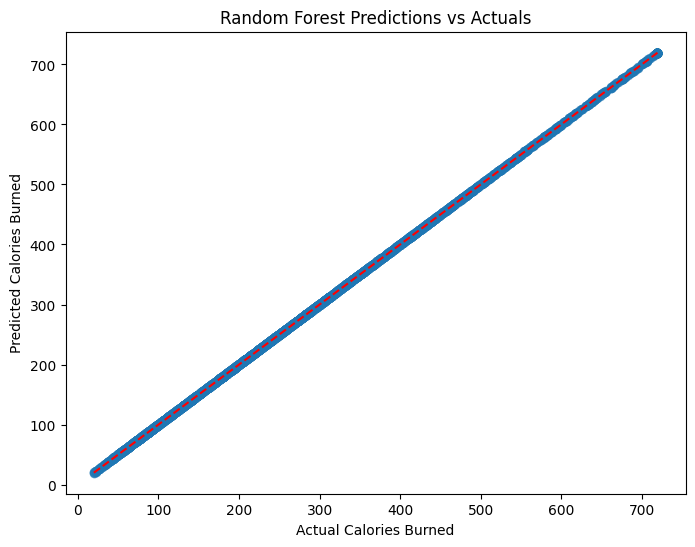

In [47]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "KNN": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "SVR": SVR(),
    "XGBoost": XGBRegressor()
}

results = []
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model","MAE","RMSE","R2"])
print("All models evaluated:\n", results_df.sort_values(by="R2", ascending=False))

best_model_name = results_df.sort_values(by="R2", ascending=False).iloc[0,0]
print("\n✅ Best Model chosen based on R²:", best_model_name)

best_model = models[best_model_name]
y_pred = best_model.predict(X_test)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Calories Burned")
plt.ylabel("Predicted Calories Burned")
plt.title(f"{best_model_name} Predictions vs Actuals")
plt.show()


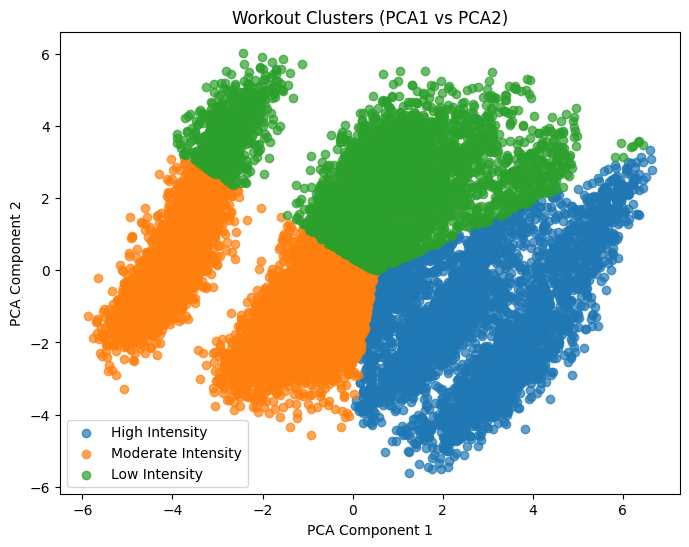

In [49]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv("/content/FE+Preprocessing.csv")
non_numeric = ['Gender', 'Age_Group', 'Workout_Intensity']
df_numeric = df.drop(columns=[col for col in non_numeric if col in df.columns])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(pca_data)

plt.figure(figsize=(8,6))

cluster_mapping = {0: "High Intensity", 1: "Moderate Intensity", 2: "Low Intensity"}

for cluster_id, cluster_name in cluster_mapping.items():
    plt.scatter(
        pca_data[labels == cluster_id, 0],  # PCA1
        pca_data[labels == cluster_id, 1],  # PCA2
        label=cluster_name,
        alpha=0.7
    )

plt.title("Workout Clusters (PCA1 vs PCA2)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()


In [ ]:
#Business Insights

The clustering and calorie‑burn prediction model has direct applications in the fitness and health industry

#1.Wearable Fitness Apps
- Real‑time calorie burn prediction during workouts.
- Enables smartwatches and trackers to provide -instant feedback on energy expenditure.

#2.Personalized Fitness Coaching
- Clusters (High, Moderate, Low intensity) guide -custom workout recommendations
- Coaches and apps can tailor duration and intensity suggestions for each user segment.

#3.Health Monitoring Platforms
- Predicted energy expenditure supports -nutrition and diet planning
- Helps users maintain calorie balance for weight management and medical monitoring.

#4.User Segmentation
- Unsupervised clustering identifies -workout behavior patterns without labels.
- Segments like “Weekend Warriors” vs. “Daily Moderate Exercisers” enable targeted programs.

#5.Product Optimization
- Feature importance(heart rate, hydration, BMI, effort score) provides -insights for device manufacturers
- Guides improvements in sensors, algorithms, and user interfaces for fitness devices.
